# Beadandó házifeladat





1. A kapott adatokhoz milyen típusú adatbázist érdemes használni, és miért?

2. Tervezzék meg az adatbázist ER diagram segítségével. Lehet, hogy néhányszor újra fogják tervezni, ezeknek a miértjét és eredményeit nyugodtan írják le.

3. Hozzák létre az adatbázist. A választott metódust indokolják meg.

4. Töltsék fel az adatokat a csv fájlokból a megfelelő táblákba. Ellenőrizzék az adatok és az adattípusok helyességét!


A fenti négy kérdés megválaszolásához először Python segítségével vizsgáltam meg az adatokat.

### `Adagok.csv`

A lenti kóddal először beolvastam az `Adagok.csv` file-t. Ehhez a `pandas` könyvtár `read_csv` függvényét használtam.

Első nekifutásra  a kódolással adódott gond az alapértelemezett `UTF8` kódolás hibát dobott. Más kódolással is próbálkoztam, de egy darabig nem sikerült megtalálni, a file eredeti kódolását. Ezért átmeneti megoldásként szövegszerkesztőben átírtam az oszlopneveket és azt használtam. Kicsival később AI segítésgével  sikerült megfejteni, hogy az eredeti kódolás `DOS852` lehetett és az `encoding="CP852"` paraméterrel a beolvasás sikeres volt.

Ezután nem kaptam értelmes eredményt, mert az elválasztó karakter nem vessző, hanem pontos vessző van. Ezt be lehet állítani a `sep` argumentum segítségével. 

Az adatokat áttekintve kiderült, hogy a kb. 10000 sorból csak 32-ben vannak adatok és ezek is redundánsak, pl. az `ADAGIDŐ` az adag kezdete és vége időpontból kiszámolható. Az `ADAGKÖZI IDŐ` is redundáns, másrészt nem derül ki pontosan mit is jelent, ezért ezt is el hagytam. 

A `DÁTUM` és `IDŐ` oszlopokat összevontam egy egyetlen dátum-idő típusú oszlopba.

Végül az `ADAGSZÁM` oszlopot egész típusúra alakitottam, mert ez egy egyedi azonosító ebben a táblázatban. 

### `Hűtőpanelek.csv`

Ebben a fileban párban vannak az oszlopok. Minden panelhez tartozik egy időpont oszlop és egy hőmérséklet oszlop. Az érték oszlopokban a tizedes pont helyett tizedesvessző van, ezért a beolvasásnál a `decimal=","` paraméteret is megadtam.

Ellenőriztem, hogy egy sorban a iőpont adatok megegyeznek, vagyis egy sorban egyetlen időponthoz tartozó mérési eredmények vannak. Ezért a felesleges időpont oszlopokat elhagytam. 

Ez a formátum nem a legkönnyebben kezelhető, ezért következő lépésben a `pandas` könyvtár `wide_to_long` függvényével hosszú formátumúra alakítottam.

A kapott táblázatban három oszlop szerepel az időpont, a panel sorszáma, ill a mért hőmérséklet.
Itt az időpont és a panel sorszáma index.




## 1. kérdés

A kapott adatokhoz egy hagyományos `sql` alapú adatbázis megfelelő. Nincs szükség a `nosql` adatbázisok nyújtotta rugalmasságra. A választásom az `sqlite3` adatbázis kezelőre esett, egyrészt mert órai anyagban is ezt használtuk legtöbbször, másrészt adminisztrációs szempontból ez a legegyszerűbb. Az adatokat a helyi lemezen egy `.db` kiterjesztésű fileben tárolja. Az egyszerűség kedvéért a projekt könyvtáron belül létrehoztam egy `data` könyvtárat, ide kerültek a forrás adatok és a `data.db` adatbázis file is.



## 2. kérdés

A végső táblázatok között a kapcsolatot a mérés ideje ill. az adag kezdete és vége adja meg. Itt a legnagyobb problémát az ER Diagram létrehozása okozta. A `DBVisualizer` ingyenes változatában ez a funkció nem elérhető, vagy nekem nem sikerült  működésre bírni. Némi keresgélés után találtam egy eszközt, ami Jupyter notebookban is használható.



In [4]:
import base64
import io, requests
from IPython.display import Image, display
from PIL import Image as im
import matplotlib.pyplot as plt

def mm(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    img = im.open(io.BytesIO(requests.get('https://mermaid.ink/img/' + base64_string).content))
    plt.imshow(img)
    plt.axis('off') # allow to hide axis
    # plt.savefig('image.svg')



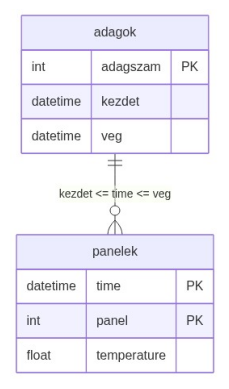

In [9]:
mm("""erDiagram
adagok {
    int adagszam PK
    datetime kezdet
    datetime veg
}
panelek {
    datetime time PK
    int panel PK
    float temperature
}
adagok ||--o{ panelek : "kezdet <= time <= veg"
""")

## 3. kérdés

### SQLite3 adatbázis létrehozása

A legegyszerűbb módszert választottam. Pythonban előkészítettem az adatokat és azokat a `pandas` `to_sql` függvényével küldtem át az `sqlite3` adatbázisba. Előnye ennek a módszernek (egyben a veszélye is), hogy a létező táblát felülírja, így a próbálkozások között nem kellett törölni a korábbi próbálkozások eredményét. 



In [ ]:
import pandas as pd
import sqlite3

## `Adagok.csv`

A beolvasás hibát dobott.

In [56]:
try:
    adagok = pd.read_csv('data/adagok.csv', sep=';')
except Exception as e:
    print(f"Hiba történt: {e}")


Hiba történt: 'utf-8' codec can't decode byte 0xb5 in position 6: invalid start byte


In [57]:
try:
    adagok = pd.read_csv('data/adagok.csv', sep=';', encoding="CP852")
except Exception as e:
    print(f"Hiba történt: {e}")
adagok.columns

Index(['ADAGSZÁM', 'Kezdet_DÁTUM', 'Kezdet_IDŐ', 'Vége_DÁTUM', 'Vége_IDŐ',
       'ADAGKÖZI IDŐ', 'ADAGIDŐ'],
      dtype='str')

Megvizsgálva az első sort látszik, hogy ay ékezetes karakterek kódolása okozhat problémát.
A fájl megnyitásakor meg kell adni a helyes kódolást, például UTF-8-at.

Próbálkoztam a `LATIN-1`, `CP1252` ill. `ASCII` kódolással, Ezek között volt ami nem dobott hibát, de egyik esetben jelentek meg az oszlopnevek helyesen. 

Ezek után szövegszerkesztővel megnyitva a fájlt, az első sort átírtam a helyes nevekre, a filet `adagok-utf8.csv` néven mentettem el. A továbbiakban ezzel dolgozom.

Később AI segítségével  sikerült beazonosítani a kódolást, mint CP852.



In [58]:
try:
    adagok = pd.read_csv('data/adagok-utf8.csv', sep=';')
except Exception as e:
    print(f"Hiba történt: {e}")
adagok.columns

Index(['ADAGSZÁM', 'Kezdet_DÁTUM', 'Kezdet_IDŐ', 'Vége_DÁTUM', 'Vége_IDŐ',
       'ADAGKÖZI IDŐ', 'ADAGIDŐ'],
      dtype='str')

In [59]:
adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ADAGSZÁM      32 non-null     float64
 1   Kezdet_DÁTUM  32 non-null     str    
 2   Kezdet_IDŐ    32 non-null     str    
 3   Vége_DÁTUM    32 non-null     str    
 4   Vége_IDŐ      32 non-null     str    
 5   ADAGKÖZI IDŐ  32 non-null     float64
 6   ADAGIDŐ       32 non-null     float64
dtypes: float64(3), str(4)
memory usage: 586.2 KB


In [60]:
adagok.head()

,ADAGSZÁM,Kezdet_DÁTUM,Kezdet_IDŐ,Vége_DÁTUM,Vége_IDŐ,ADAGKÖZI IDŐ,ADAGIDŐ
0,1.0,2024.07.17,17:49:00,2024.07.18,1:00:00,0.0,431.0
1,2.0,2024.07.18,1:00:00,2024.07.18,2:22:00,0.0,82.0
2,3.0,2024.07.18,2:22:00,2024.07.18,3:36:00,0.0,74.0
3,4.0,2024.07.18,3:36:00,2024.07.18,4:43:00,0.0,67.0
4,5.0,2024.07.18,4:43:00,2024.07.18,5:41:00,0.0,58.0


In [61]:
adagok.tail()

,ADAGSZÁM,Kezdet_DÁTUM,Kezdet_IDŐ,Vége_DÁTUM,Vége_IDŐ,ADAGKÖZI IDŐ,ADAGIDŐ
10711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10715,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Úgy tűnik a táblázat végén sok a hiányzó adat, kitöröljük ezeket az adatokat a táblázatból.

In [62]:
adagok = adagok.dropna(axis=0, how='all')
adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ADAGSZÁM      32 non-null     float64
 1   Kezdet_DÁTUM  32 non-null     str    
 2   Kezdet_IDŐ    32 non-null     str    
 3   Vége_DÁTUM    32 non-null     str    
 4   Vége_IDŐ      32 non-null     str    
 5   ADAGKÖZI IDŐ  32 non-null     float64
 6   ADAGIDŐ       32 non-null     float64
dtypes: float64(3), str(4)
memory usage: 1.9 KB


A több mint tízezer sorból csupán 32 maradt.

Az látszik, hogy és idő  oszlopok string típusúak. Ezeket összevontam egyetlen `datetime` típusú oszlopba. 

In [63]:
adagok["Kezdet"] = pd.to_datetime(
    adagok["Kezdet_DÁTUM"]+adagok["Kezdet_IDŐ"], 
    format="%Y.%m.%d%H:%M:%S"
)
adagok["Vége"] = pd.to_datetime(
    adagok["Vége_DÁTUM"]+adagok["Vége_IDŐ"],
    format="%Y.%m.%d%H:%M:%S"
) 

adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ADAGSZÁM      32 non-null     float64       
 1   Kezdet_DÁTUM  32 non-null     str           
 2   Kezdet_IDŐ    32 non-null     str           
 3   Vége_DÁTUM    32 non-null     str           
 4   Vége_IDŐ      32 non-null     str           
 5   ADAGKÖZI IDŐ  32 non-null     float64       
 6   ADAGIDŐ       32 non-null     float64       
 7   Kezdet        32 non-null     datetime64[us]
 8   Vége          32 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(3), str(4)
memory usage: 2.4 KB


Az ADAGSZÁM változó típusa float64 - lebegőpontos szám - ezt célszerű egész tipusúvá alakítani, mert ez egy sorszám.

In [64]:
adagok["ADAGSZÁM"] = adagok["ADAGSZÁM"].astype(int)
adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ADAGSZÁM      32 non-null     int64         
 1   Kezdet_DÁTUM  32 non-null     str           
 2   Kezdet_IDŐ    32 non-null     str           
 3   Vége_DÁTUM    32 non-null     str           
 4   Vége_IDŐ      32 non-null     str           
 5   ADAGKÖZI IDŐ  32 non-null     float64       
 6   ADAGIDŐ       32 non-null     float64       
 7   Kezdet        32 non-null     datetime64[us]
 8   Vége          32 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(1), str(4)
memory usage: 2.4 KB


### Egy gyors ellenőrzés szemrevételezéssel


In [65]:
adagok.loc(1)["Kezdet", "Kezdet_DÁTUM", "Kezdet_IDŐ", "Vége", "Vége_DÁTUM", "Vége_IDŐ"]

,Kezdet,Kezdet_DÁTUM,Kezdet_IDŐ,Vége,Vége_DÁTUM,Vége_IDŐ
0,2024-07-17 17:49:00,2024.07.17,17:49:00,2024-07-18 01:00:00,2024.07.18,1:00:00
1,2024-07-18 01:00:00,2024.07.18,1:00:00,2024-07-18 02:22:00,2024.07.18,2:22:00
2,2024-07-18 02:22:00,2024.07.18,2:22:00,2024-07-18 03:36:00,2024.07.18,3:36:00
3,2024-07-18 03:36:00,2024.07.18,3:36:00,2024-07-18 04:43:00,2024.07.18,4:43:00
4,2024-07-18 04:43:00,2024.07.18,4:43:00,2024-07-18 05:41:00,2024.07.18,5:41:00
5,2024-07-18 05:41:00,2024.07.18,5:41:00,2024-07-18 06:53:00,2024.07.18,6:53:00
6,2024-07-18 06:53:00,2024.07.18,6:53:00,2024-07-18 08:05:00,2024.07.18,8:05:00
7,2024-07-18 08:05:00,2024.07.18,8:05:00,2024-07-18 09:18:00,2024.07.18,9:18:00
8,2024-07-18 09:18:00,2024.07.18,9:18:00,2024-07-18 10:19:00,2024.07.18,10:19:00
9,2024-07-18 10:19:00,2024.07.18,10:19:00,2024-07-18 11:29:00,2024.07.18,11:29:00


Így a DÁTUM és IDŐ oszlopok feleslegessé váltak, ezeket el lehet távolítani:

In [66]:
adagok = adagok.drop(columns=["Kezdet_DÁTUM", "Kezdet_IDŐ", "Vége_DÁTUM", "Vége_IDŐ"])
adagok.head()

,ADAGSZÁM,ADAGKÖZI IDŐ,ADAGIDŐ,Kezdet,Vége
0,1,0.0,431.0,2024-07-17 17:49:00,2024-07-18 01:00:00
1,2,0.0,82.0,2024-07-18 01:00:00,2024-07-18 02:22:00
2,3,0.0,74.0,2024-07-18 02:22:00,2024-07-18 03:36:00
3,4,0.0,67.0,2024-07-18 03:36:00,2024-07-18 04:43:00
4,5,0.0,58.0,2024-07-18 04:43:00,2024-07-18 05:41:00


Valójában az `ADAGIDŐ` oszlop is felesleges, mert az nem más mint a `Vége` és a `Kezdet` oszlopok különbsége, percekben kifejezve.

In [67]:

all((adagok.Vége - adagok.Kezdet).dt.total_seconds() / 60 == adagok.ADAGIDŐ)

True

Ez a oszlop is elhagyható, mert nem hordoz új információt. Végül az `ADAGKÖZI IDŐ` oszlop csupa nulla értéket tartalmaz, ráadásul nem derül ki, hogy az előző vagy a következő adag időintervallumát veszi figyelembe.


In [68]:
adagok = adagok.drop(columns=["ADAGKÖZI IDŐ", "ADAGIDŐ"])
adagok

,ADAGSZÁM,Kezdet,Vége
0,1,2024-07-17 17:49:00,2024-07-18 01:00:00
1,2,2024-07-18 01:00:00,2024-07-18 02:22:00
2,3,2024-07-18 02:22:00,2024-07-18 03:36:00
3,4,2024-07-18 03:36:00,2024-07-18 04:43:00
4,5,2024-07-18 04:43:00,2024-07-18 05:41:00
5,6,2024-07-18 05:41:00,2024-07-18 06:53:00
6,7,2024-07-18 06:53:00,2024-07-18 08:05:00
7,8,2024-07-18 08:05:00,2024-07-18 09:18:00
8,9,2024-07-18 09:18:00,2024-07-18 10:19:00
9,10,2024-07-18 10:19:00,2024-07-18 11:29:00


## Adatbázis létrehozása

Ez lesz az adatbázis egyik táblája. Az adatbázist az `sqlite3`  segítségével hozzuk létre. 

In [69]:
import sqlite3

with sqlite3.connect("data/data.db", timeout=30) as conn:
    adagok.to_sql("adagok", conn, index=False, if_exists="replace")

Ellenőrizzük SQL kóddal hogy mit tartalmaz az `adagok` tábla.

In [70]:
with sqlite3.connect("data/data.db") as conn:
    pd.read_sql("SELECT * FROM adagok LIMIT 5", conn)

## `Hűtőpanelek.csv`

A beolvasásnál figyelni kell arra, hogy a  file valójában `csv2` formátumú, a mezőszeparátor pontosvessző, a tizedes jel pedig  vessző az alapértlemezett pont helyett.

A Hűtőpanelek.csv adatai között vannak megegyező adatok, ezeket tömbbösítve használjuk fel.

In [71]:
try:
    hutopanelek = pd.read_csv('data/Hutopanelek.csv', sep=';', decimal=',')
except Exception as e:
    print(f"Hiba történt: {e}")

In [72]:
hutopanelek.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Panel hőfok 1 [°C] Time     86400 non-null  str    
 1   Panel hőfok 1 [°C] ValueY   86400 non-null  float64
 2   Panel hőfok 2 [°C] Time     86400 non-null  str    
 3   Panel hőfok 2 [°C] ValueY   86400 non-null  float64
 4   Panel hőfok 3 [°C] Time     86400 non-null  str    
 5   Panel hőfok 3 [°C] ValueY   86400 non-null  float64
 6   Panel hőfok 4 [°C] Time     86400 non-null  str    
 7   Panel hőfok 4 [°C] ValueY   86400 non-null  float64
 8   Panel hőfok 5 [°C] Time     86400 non-null  str    
 9   Panel hőfok 5 [°C] ValueY   86400 non-null  float64
 10  Panel hőfok 6 [°C] Time     86400 non-null  str    
 11  Panel hőfok 6 [°C] ValueY   86400 non-null  float64
 12  Panel hőfok 8 [°C] Time     86400 non-null  str    
 13  Panel hőfok 8 [°C] ValueY   86400 non-null

In [73]:
hutopanelek.head()

,Panel hőfok 1 [°C] Time,Panel hőfok 1 [°C] ValueY,Panel hőfok 2 [°C] Time,Panel hőfok 2 [°C] ValueY,Panel hőfok 3 [°C] Time,Panel hőfok 3 [°C] ValueY,Panel hőfok 4 [°C] Time,Panel hőfok 4 [°C] ValueY,Panel hőfok 5 [°C] Time,Panel hőfok 5 [°C] ValueY,...,Panel hőfok 11 [°C] Time,Panel hőfok 11 [°C] ValueY,Panel hőfok 12 [°C] Time,Panel hőfok 12 [°C] ValueY,Panel hőfok 13 [°C] Time,Panel hőfok 13 [°C] ValueY,Panel hőfok 14 [°C] Time,Panel hőfok 14 [°C] ValueY,Panel hőfok 15 [°C] Time,Panel hőfok 15 [°C] ValueY
0,2024.07.18 14:01:52,41.599998,2024.07.18 14:01:52,35.099998,2024.07.18 14:01:52,36.5,2024.07.18 14:01:52,40.599998,2024.07.18 14:01:52,41.000000,...,2024.07.18 14:01:52,43.799999,2024.07.18 14:01:52,40.200001,2024.07.18 14:01:52,37.599998,2024.07.18 14:01:52,45.299999,2024.07.18 14:01:52,41.5
1,2024.07.18 14:01:53,41.599998,2024.07.18 14:01:53,35.099998,2024.07.18 14:01:53,36.5,2024.07.18 14:01:53,40.599998,2024.07.18 14:01:53,41.000000,...,2024.07.18 14:01:53,43.799999,2024.07.18 14:01:53,40.200001,2024.07.18 14:01:53,37.599998,2024.07.18 14:01:53,45.299999,2024.07.18 14:01:53,41.5
2,2024.07.18 14:01:54,41.700001,2024.07.18 14:01:54,35.099998,2024.07.18 14:01:54,36.5,2024.07.18 14:01:54,40.599998,2024.07.18 14:01:54,41.000000,...,2024.07.18 14:01:54,43.799999,2024.07.18 14:01:54,40.200001,2024.07.18 14:01:54,37.599998,2024.07.18 14:01:54,45.299999,2024.07.18 14:01:54,41.5
3,2024.07.18 14:01:55,41.700001,2024.07.18 14:01:55,35.099998,2024.07.18 14:01:55,36.5,2024.07.18 14:01:55,40.599998,2024.07.18 14:01:55,41.099998,...,2024.07.18 14:01:55,43.799999,2024.07.18 14:01:55,40.200001,2024.07.18 14:01:55,37.599998,2024.07.18 14:01:55,45.299999,2024.07.18 14:01:55,41.5
4,2024.07.18 14:01:56,41.700001,2024.07.18 14:01:56,35.099998,2024.07.18 14:01:56,36.5,2024.07.18 14:01:56,40.599998,2024.07.18 14:01:56,41.099998,...,2024.07.18 14:01:56,43.799999,2024.07.18 14:01:56,40.200001,2024.07.18 14:01:56,37.599998,2024.07.18 14:01:56,45.299999,2024.07.18 14:01:56,41.5


Látszik, hogy párban vannak az adatok. 15 panelekben vannak az adatok, minden panelhez tartozik egy hőmérséklet és egy hőfok.

Úgy tűnik egy soron belül az időpontok azonosak. Ezt leellenőrizzük.

In [74]:
time_cols = [colname for colname in hutopanelek.columns if "Time" in colname]
time_cols 

['Panel hőfok 1 [°C] Time',
 'Panel hőfok 2 [°C] Time',
 'Panel hőfok 3 [°C] Time',
 'Panel hőfok 4 [°C] Time',
 'Panel hőfok 5 [°C] Time',
 'Panel hőfok 6 [°C] Time',
 'Panel hőfok 8 [°C] Time',
 'Panel hőfok 9 [°C] Time',
 'Panel hőfok 10 [°C] Time',
 'Panel hőfok 11 [°C] Time',
 'Panel hőfok 12 [°C] Time',
 'Panel hőfok 13 [°C] Time',
 'Panel hőfok 14 [°C] Time',
 'Panel hőfok 15 [°C] Time']

In [75]:
def identical(a, b):
    return a.equals(b)

all(identical(hutopanelek[col], hutopanelek[time_cols[0]]) for col in time_cols)


True

In [76]:
hutopanelek = hutopanelek.drop(columns=time_cols[1:])

A megmaradó időpont oszlop típusát szövegről `date.time`-ra érdemes állítani. 

In [77]:
hutopanelek[time_cols[0]] = hutopanelek[time_cols[0]].astype("datetime64[ns]")
hutopanelek.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Panel hőfok 1 [°C] Time     86400 non-null  datetime64[ns]
 1   Panel hőfok 1 [°C] ValueY   86400 non-null  float64       
 2   Panel hőfok 2 [°C] ValueY   86400 non-null  float64       
 3   Panel hőfok 3 [°C] ValueY   86400 non-null  float64       
 4   Panel hőfok 4 [°C] ValueY   86400 non-null  float64       
 5   Panel hőfok 5 [°C] ValueY   86400 non-null  float64       
 6   Panel hőfok 6 [°C] ValueY   86400 non-null  float64       
 7   Panel hőfok 8 [°C] ValueY   86400 non-null  float64       
 8   Panel hőfok 9 [°C] ValueY   86400 non-null  float64       
 9   Panel hőfok 10 [°C] ValueY  86400 non-null  float64       
 10  Panel hőfok 11 [°C] ValueY  86400 non-null  float64       
 11  Panel hőfok 12 [°C] ValueY  86400 non-null  float64       
 12  P

A táblazat ebben az alakban széles formátumú. Könnyebb dolgozni vele, ha hosszú formátumban van, azaz minden mérési időponthoz és panelhez tartozik egy sor, ami a panel hőmérsékletét tartalmazza az adott mérési időpontban. 

Az átalakításhoz a neveket célszerű először átalakítani.

In [78]:
hutopanelek.columns = (hutopanelek.columns.
    str.replace(time_cols[0], "Time").
    str.replace("Panel hőfok", "Temperature").
    str.replace("[°C] ValueY", "").
    str.strip()
)
hutopanelek.columns

Index(['Time', 'Temperature 1', 'Temperature 2', 'Temperature 3',
       'Temperature 4', 'Temperature 5', 'Temperature 6', 'Temperature 8',
       'Temperature 9', 'Temperature 10', 'Temperature 11', 'Temperature 12',
       'Temperature 13', 'Temperature 14', 'Temperature 15'],
      dtype='str')

In [79]:
panelek = pd.wide_to_long(hutopanelek, stubnames="Temperature ", i="Time", j="Panel")

In [80]:
panelek.columns = panelek.columns.str.strip()
panelek.head()

,,Temperature
Time,Panel,
2024-07-18 14:01:52,1,41.599998
2024-07-18 14:01:53,1,41.599998
2024-07-18 14:01:54,1,41.700001
2024-07-18 14:01:55,1,41.700001
2024-07-18 14:01:56,1,41.700001


In [81]:
panelek.info()

<class 'pandas.DataFrame'>
MultiIndex: 1209600 entries, (Timestamp('2024-07-18 14:01:52'), np.int64(1)) to (Timestamp('2024-07-19 14:01:51'), np.int64(15))
Data columns (total 1 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Temperature  1209600 non-null  float64
dtypes: float64(1)
memory usage: 15.7 MB


Kiírjuk a táblázatot az adatbázisba. Ellenőrzésképpen visszaolvassuk SQL segítségével.

In [82]:
with sqlite3.connect("data/data.db", timeout=30) as conn:
    panelek.to_sql("panelek", conn, index=True, if_exists="replace")

In [83]:
with sqlite3.connect("data/data.db") as conn:
    pd.read_sql("SELECT * FROM  panelek LIMIT 5", conn)

## ADATBÁZIS LEKÉRDEZÉSEK / ELEMZÉS

Kérdések:

1. Mely panelek érik el vagy lépik át a 100 °C-ot?
2. Mely időpontokban fordul elő túlhevülés az egyes panelek esetében?
3. Mely adagok feldolgozása során nem maradnak a panelek a megengedett hőmérsékleti tartományban?
4. Mi az átlag, maximum és minimum hőmérséklet az egyes adagok feldolgozása során az egyes panelek esetében? 
5. Melyik panelnek a megadott időben milyen minimumon és maximumon volt a hőmérséklete?
6. Van-e olyan panel, amely mindig a megengedett hőmérsékleti tartományban marad?
7. Van-e olyan panel, amely adott adag feldolgozása során túlhevül?

In [84]:
%%capture
%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT'
%sql sqlite:///data/data.db

Először is betöltjük a hozzáadott SQL kiegészítőt, ebben az esetben ez SQLite3-at választottam, mert olyan előnyei vannak, mint az önállóság, a hatékonyság és a nyílt forráskód, szerver nélkül. Korlátai is vannak a skálázhatóságnak és a párhuzamosságnak, ami befolyásolhatja a nagyméretű alkalmazásokat.

In [85]:
%%sql
SELECT * FROM panelek limit 5;

 * sqlite:///data/data.db
Done.


Time,Panel,Temperature
2024-07-18 14:01:52,1,41.59999847
2024-07-18 14:01:53,1,41.59999847
2024-07-18 14:01:54,1,41.70000076
2024-07-18 14:01:55,1,41.70000076
2024-07-18 14:01:56,1,41.70000076


In [86]:
%%sql

SELECT distinct Panel FROM panelek
WHERE Temperature >= 100;

 * sqlite:///data/data.db
Done.


Panel
6
11


Az első kérdésre adott válasz tehát a 6. és 11. panel lépi át a hőhatárt.

In [87]:
%%sql
SELECT time, panel FROM panelek
WHERE Temperature >= 100
ORDER BY panel, time
LIMIT 10;

 * sqlite:///data/data.db


Done.


Time,Panel
2024-07-19 01:01:06,6
2024-07-19 01:01:07,6
2024-07-19 01:01:08,6
2024-07-19 01:01:09,6
2024-07-19 01:01:10,6
2024-07-19 01:01:11,6
2024-07-19 01:01:12,6
2024-07-19 01:01:13,6
2024-07-19 01:01:14,6
2024-07-19 01:01:15,6


In [88]:
%%sql

SELECT 
    time, 
    unixepoch(time) - row_number() over (partition by panel order by time) as group_id,
    panel 
FROM
(select time, panel FROM panelek
WHERE Temperature >= 100
ORDER BY panel, time
)
LIMIT 10;

 * sqlite:///data/data.db


Done.


time,group_id,panel
2024-07-19 01:01:06,1721350865,6
2024-07-19 01:01:07,1721350865,6
2024-07-19 01:01:08,1721350865,6
2024-07-19 01:01:09,1721350865,6
2024-07-19 01:01:10,1721350865,6
2024-07-19 01:01:11,1721350865,6
2024-07-19 01:01:12,1721350865,6
2024-07-19 01:01:13,1721350865,6
2024-07-19 01:01:14,1721350865,6
2024-07-19 01:01:15,1721350865,6


In [89]:
%%sql
SELECT
    min(time) AS start_time,
    max(time) AS end_time,
    min(panel) AS panel
FROM (
SELECT 
    time, 
    unixepoch(time) - row_number() over (partition by panel order by time) AS group_id,
    panel 
FROM
(SELECT time, panel FROM panelek
WHERE Temperature >= 100
ORDER BY panel, time
))
GROUP BY panel, group_id
LIMIT 50;

 * sqlite:///data/data.db
Done.


start_time,end_time,panel
2024-07-19 01:01:06,2024-07-19 01:34:45,6
2024-07-19 02:18:02,2024-07-19 02:43:00,6
2024-07-19 04:48:09,2024-07-19 05:05:32,6
2024-07-19 05:52:53,2024-07-19 06:08:34,6
2024-07-19 06:53:11,2024-07-19 07:11:40,6
2024-07-18 22:01:49,2024-07-18 22:01:49,11
2024-07-18 22:07:09,2024-07-18 22:07:09,11
2024-07-19 00:36:54,2024-07-19 00:36:54,11
2024-07-19 00:37:10,2024-07-19 00:37:10,11
2024-07-19 00:43:57,2024-07-19 00:43:57,11


In [90]:
%%sql
WITH hot_panels AS (
SELECT time, panel from panelek
WHERE Temperature >= 100
ORDER BY panel, time
),
grouped_hot_panels AS (
SELECT 
    time, 
    unixepoch(time) - row_number() over (partition by panel order by time) AS group_id,
    panel 
FROM hot_panels
)
SELECT
    MIN(time) as start_time,
    MAX(time) as end_time,
    MIN(panel) as panel
FROM grouped_hot_panels
GROUP BY panel, group_id
LIMIT 20;


 * sqlite:///data/data.db
Done.


start_time,end_time,panel
2024-07-19 01:01:06,2024-07-19 01:34:45,6
2024-07-19 02:18:02,2024-07-19 02:43:00,6
2024-07-19 04:48:09,2024-07-19 05:05:32,6
2024-07-19 05:52:53,2024-07-19 06:08:34,6
2024-07-19 06:53:11,2024-07-19 07:11:40,6
2024-07-18 22:01:49,2024-07-18 22:01:49,11
2024-07-18 22:07:09,2024-07-18 22:07:09,11
2024-07-19 00:36:54,2024-07-19 00:36:54,11
2024-07-19 00:37:10,2024-07-19 00:37:10,11
2024-07-19 00:43:57,2024-07-19 00:43:57,11


A második kérdésre adott válasz tehát ezekben az időpontokban voltak 100 °C felett a megadott 6. és 11. panelek.

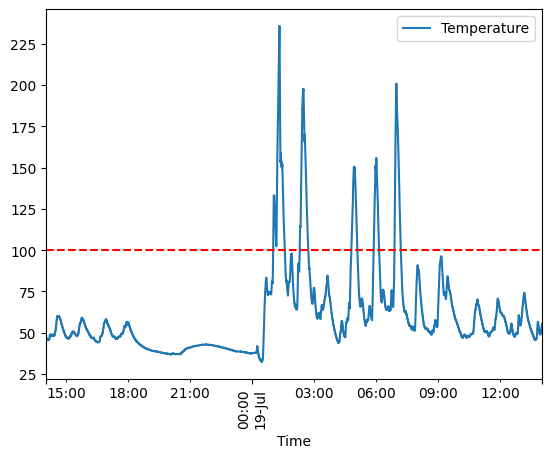

In [91]:
ax = panelek.loc(0)[:, 6].reset_index().plot(x="Time", y="Temperature")
ax.axhline(y=100, color='red', linestyle='--')
ax.tick_params(axis='x', rotation=90)
None

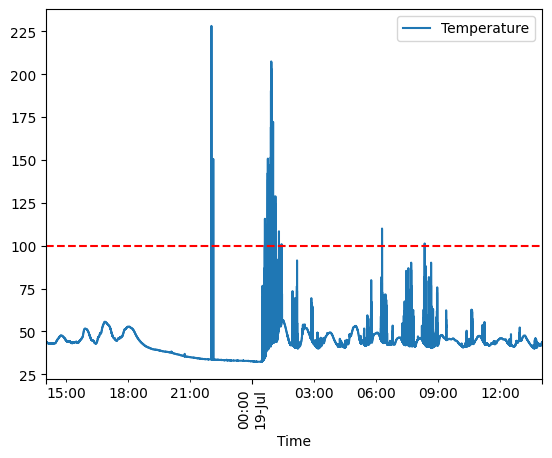

In [92]:
ax = panelek.loc(0)[:, 11].reset_index().plot(x="Time", y="Temperature")
ax.axhline(y=100, color='red', linestyle='--')
ax.tick_params(axis='x', rotation=90)
None

In [ ]:
%%sql

SELECT
    adag_id,
    ROUND(MAX(temperature), 2) AS max_temperature,
    panel
FROM (
    SELECT 
        time, 
        panel,
        temperature,
        `ADAGSZÁM` AS adag_id
        FROM panelek
        LEFT JOIN adagok 
        ON panelek.time BETWEEN adagok.Kezdet AND adagok.Vége
)
GROUP BY adag_id, panel
HAVING MAX(temperature) >= 100;

 * sqlite:///data/data.db
Done.


adag_id,max_temperature,panel
17,235.8,6
17,228.2,11
18,197.6,6
19,117.8,6
20,150.5,6
21,155.8,6
22,200.8,6
22,110.0,11
23,148.5,6
24,101.3,11


A harmadik kérdésre adott válasz tehát ezek a kiugró hőmérsékleti értékek a 6. és a 11. paneleken.

In [110]:
%%sql
INSERT INTO adagok (ADAGSZÁM, Kezdet, Vége)
VALUES (999, '2024-07-18 14:00:00', '2024-07-18 18:00:00' ), (998, '2024-07-19 14:00:00', '2024-07-19 18:00:00' ), (997, '2024-07-20 14:00:00', '2024-07-20 18:00:00' );

 * sqlite:///data/data.db
3 rows affected.


[]

Beszúrunk 3 sort pluszban az Adagok.csv ADAGSZÁM,Kezdet, Vége celláiba értékekkel kitöltve, ezzel együtt dolgozunk tovább az adatbázisban.

In [94]:
%%sql

SELECT
    adag_id,
    panel,
    ROUND(MAX(temperature), 2) AS max_temperature,
    ROUND(MIN(temperature), 2) AS min_temperature,
    ROUND(AVG(temperature), 2) AS avg_temperature
FROM (
    SELECT 
        time, 
        panel,
        temperature,
        `ADAGSZÁM` AS adag_id
        FROM panelek
        left join adagok 
        on panelek.time between adagok.Kezdet AND adagok.Vége
)
GROUP BY adag_id, panel
-- having max(temperature) >= 100
ORDER BY adag_id, panel;

 * sqlite:///data/data.db
Done.


adag_id,panel,max_temperature,min_temperature,avg_temperature
13,1,46.7,40.4,42.99
13,2,36.0,34.9,35.37
13,3,42.3,36.3,38.64
13,4,46.0,35.2,42.41
13,5,44.6,40.8,42.7
13,6,60.1,45.5,51.49
13,8,42.9,38.9,40.32
13,9,42.9,39.1,40.31
13,10,48.9,40.0,43.09
13,11,47.6,42.9,44.08


A negyedik kérdésre adott válasz tehát ezek a maximum / minimum / átlag hőmérsékletek a mérés során a paneleken.

In [95]:
%%sql
SELECT Panel, MIN(Temperature) AS MinTemp, MAX(Temperature) AS MaxTemp
FROM panelek
WHERE Time BETWEEN '2024-07-18 14:00:00' AND '2024-07-18 18:00:00'
GROUP BY Panel
ORDER BY Panel;

 * sqlite:///data/data.db
Done.


Panel,MinTemp,MaxTemp
1,40.20000076,48.29999924
2,34.90000153,36.0
3,36.29999924,42.90000153
4,35.20000076,47.59999847
5,38.70000076,44.59999847
6,44.20000076,60.09999847
8,38.90000153,44.09999847
9,38.79999924,43.20000076
10,39.40000153,51.90000153
11,42.90000153,55.59999847


A negyedik kérdésre a válasz tehát a lekérdezett időben ezek a minimum és maximum hőmérsékleti adatok a paneleken.

In [96]:
print(f"adagok     : {adagok.Kezdet.min()}-- {adagok.Vége.max()}")
print(f"hűtőpanelek: {hutopanelek.Time.min()}-- {hutopanelek.Time.max()}")


adagok     : 2024-07-17 17:49:00-- 2024-07-19 23:09:00
hűtőpanelek: 2024-07-18 14:01:52-- 2024-07-19 14:01:51


Kiírtuk, hogy mikor a legalacsonyabb és a legmagasabb a hőmérséklet az adagokon és paneleken.

In [106]:
%%sql
SELECT
    time, panel,
    MAX(Temperature) OVER (PARTITION BY panel ORDER BY time) >= 90 AS hot,
    MIN(Temperature) OVER (PARTITION BY panel ORDER BY time) >= 90 AS hot2
FROM panelek
LIMIT 10;



 * sqlite:///data/data.db
Done.


Time,Panel,hot,hot2
2024-07-18 14:01:52,1,0,0
2024-07-18 14:01:53,1,0,0
2024-07-18 14:01:54,1,0,0
2024-07-18 14:01:55,1,0,0
2024-07-18 14:01:56,1,0,0
2024-07-18 14:01:57,1,0,0
2024-07-18 14:01:58,1,0,0
2024-07-18 14:01:59,1,0,0
2024-07-18 14:02:00,1,0,0
2024-07-18 14:02:01,1,0,0


Hatodik kérdésre a válasz tehát az 1. panel hot és a hot2-ben kiírt adatok alapján a megfelelő tartományon belül marad végig.

In [99]:
%%sql
SELECT 6 AS Panel, COUNT(*) AS Count FROM panelek 
WHERE  Panel = 6 AND Temperature >= 100
UNION
SELECT 11 AS Panel, COUNT(*) AS Count FROM panelek
WHERE  Panel = 11 AND Temperature >= 100

 * sqlite:///data/data.db
Done.


Panel,Count
6,6615
11,285


Tehát a hetedik kérdésre a válasz igen vannak ilyen panelek, a 6. és 11. panelek túlterhelődnek.

In [104]:
%%sql
SELECT Panel, COUNT(*) AS Count
FROM panelek
WHERE Temperature >= 100
GROUP BY Panel;

 * sqlite:///data/data.db
Done.


Panel,Count
6,6615
11,285


Kiegészítésképpen a 6. panel 6615 alkalommal terhelődik túl, 11. panel pedig 285 alkalommal. Ezt a lekérdezést GROUP BY clause( záradékkal ) hozzuk létre.

In [101]:
import base64
import io, requests
from IPython.display import Image, display
from PIL import Image as im
import matplotlib.pyplot as plt

def mm(graph):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    img = im.open(io.BytesIO(requests.get('https://mermaid.ink/img/' + base64_string).content))
    plt.imshow(img)
    plt.axis('off') # allow to hide axis
    # plt.savefig('image.svg')



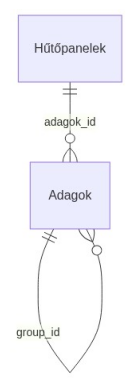

In [102]:
mm("""
erDiagram
    Adagok ||--o{ Adagok : "group_id"
    Hűtőpanelek ||--o{ Adagok : "adagok_id"
""")

Létrehozunk egy ER diagrammot amiben feltüntetjük a táblák kapcsolatát és az elsődleges kulcsokat.